In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

output_dir = "../images/EDA/"

df = pd.read_csv("../data/raw/Placement_Data.csv")

In [2]:
print(df.shape)

(215, 15)


In [3]:
df.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    str    
 2   ssc_p           215 non-null    float64
 3   ssc_b           215 non-null    str    
 4   hsc_p           215 non-null    float64
 5   hsc_b           215 non-null    str    
 6   hsc_s           215 non-null    str    
 7   degree_p        215 non-null    float64
 8   degree_t        215 non-null    str    
 9   workex          215 non-null    str    
 10  etest_p         215 non-null    float64
 11  specialisation  215 non-null    str    
 12  mba_p           215 non-null    float64
 13  status          215 non-null    str    
 14  salary          148 non-null    float64
dtypes: float64(6), int64(1), str(8)
memory usage: 25.3 KB


In [5]:
df.describe()

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
count,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,148.000000
mean,108.000000,67.303395,66.333163,66.370186,72.100558,62.278186,288655.405405
std,62.209324,10.827205,10.897509,7.358743,13.275956,5.833385,93457.452420
min,1.000000,40.890000,37.000000,50.000000,50.000000,51.210000,200000.000000
25%,54.500000,60.600000,60.900000,61.000000,60.000000,57.945000,240000.000000
50%,108.000000,67.000000,65.000000,66.000000,71.000000,62.000000,265000.000000
75%,161.500000,75.700000,73.000000,72.000000,83.500000,66.255000,300000.000000
max,215.000000,89.400000,97.700000,91.000000,98.000000,77.890000,940000.000000


In [6]:
# df.isnull().sum()

df.isnull().sum() / len(df) * 100

sl_no              0.000000
gender             0.000000
ssc_p              0.000000
ssc_b              0.000000
hsc_p              0.000000
hsc_b              0.000000
hsc_s              0.000000
degree_p           0.000000
degree_t           0.000000
workex             0.000000
etest_p            0.000000
specialisation     0.000000
mba_p              0.000000
status             0.000000
salary            31.162791
dtype: float64

## Feature Distributions

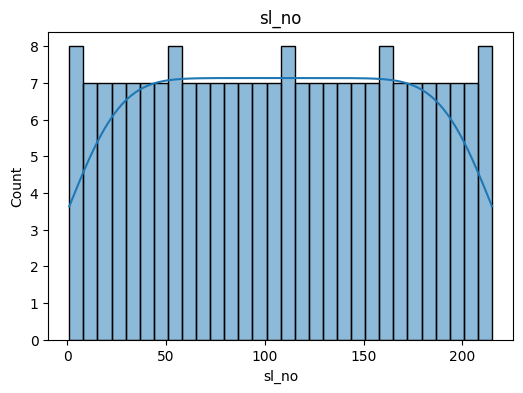

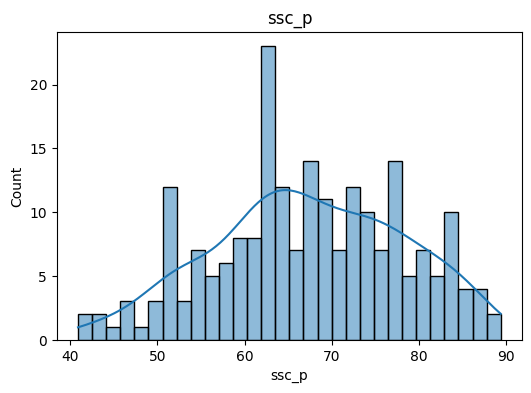

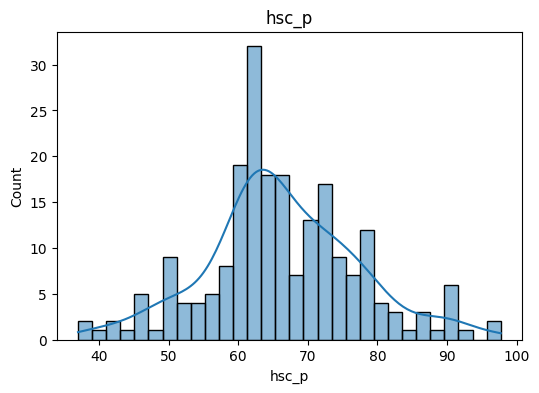

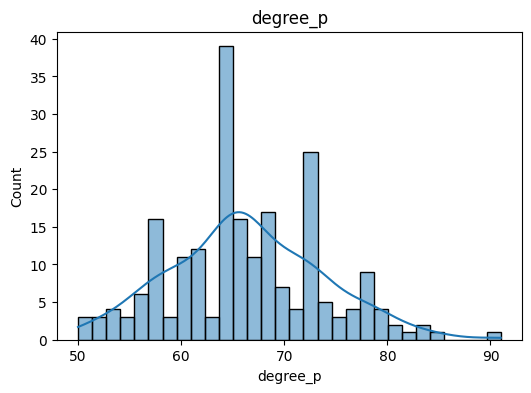

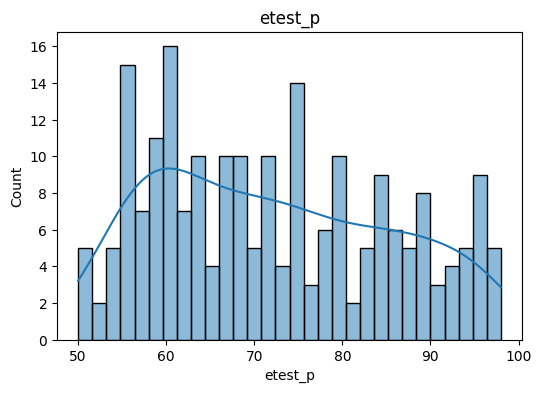

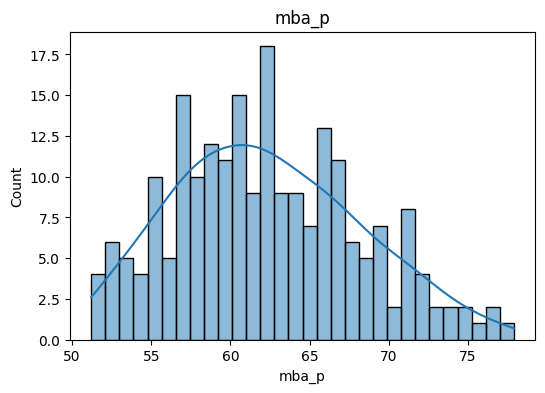

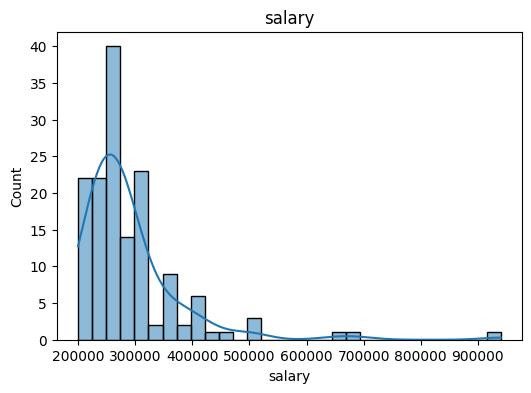

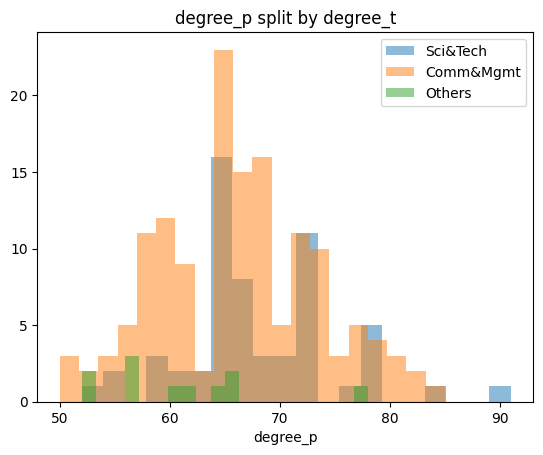

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()

for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(col)
    plt.show()


for dtype in df['degree_t'].unique():
    subset = df[df['degree_t'] == dtype]['degree_p']
    plt.hist(subset, bins=20, alpha=0.5, label=dtype)

plt.legend()
plt.title('degree_p split by degree_t')
plt.xlabel('degree_p')
plt.show()


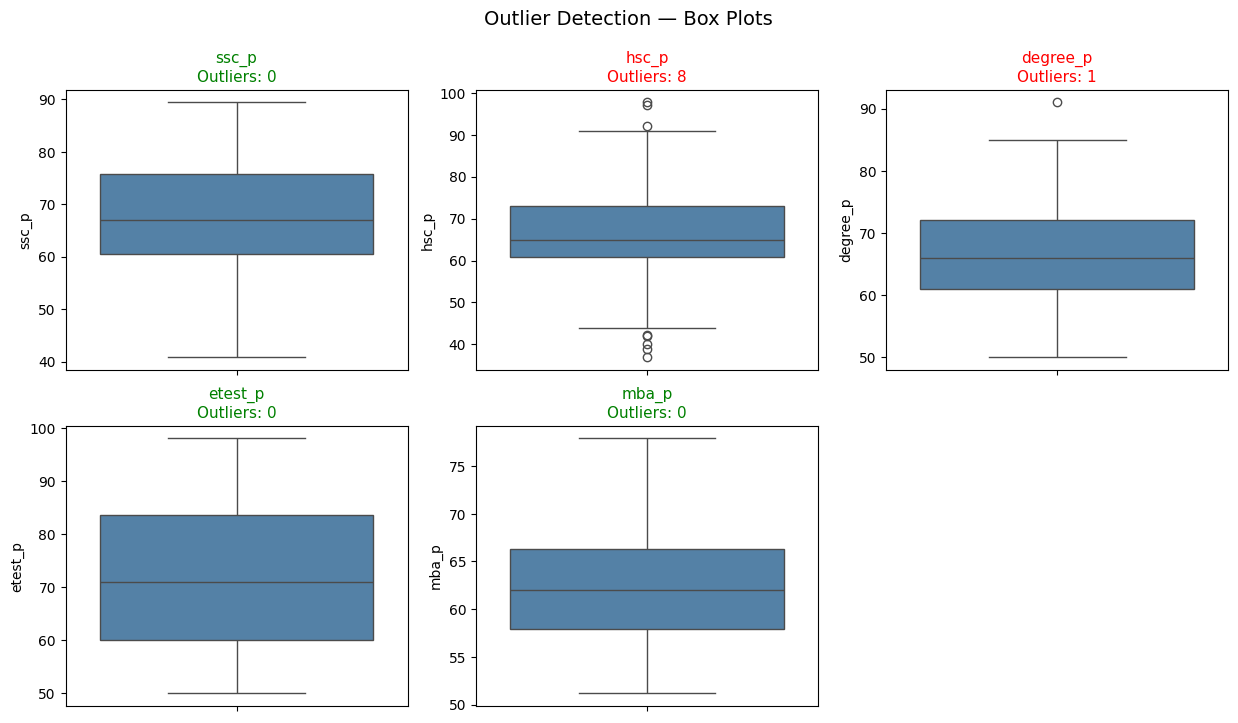

In [12]:
fig, axes = plt.subplots(2,3, figsize=(15, 8))
axes = axes.flatten()

num_cols = ['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p']

for i, col in enumerate(num_cols):
    # Calculate outliers
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    
    sns.boxplot(y=df[col], ax=axes[i], color='steelblue')
    
    # Title with outlier count, red if outliers exist
    color = 'red' if n_outliers > 0 else 'green'
    axes[i].set_title(f'{col}\nOutliers: {n_outliers}', fontsize=11, color=color)

axes[5].set_visible(False)

plt.suptitle('Outlier Detection — Box Plots', fontsize=14)
plt.show()

## Correlation Matrix

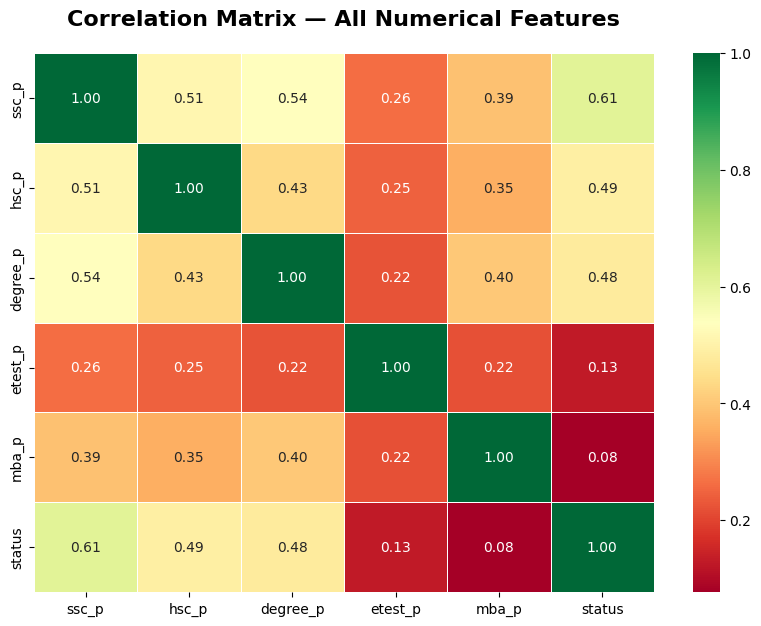

In [9]:
plt.figure(figsize=(10, 7))

# Fresh copy from original df
df_corr = df.copy()
df_corr['status'] = df_corr['status'].map({'Placed': 1, 'Not Placed': 0})

# Temporary list — don't touch num_cols
corr_cols = num_cols + ['status']
corr_matrix = df_corr[corr_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    linewidths=0.5
)

plt.title("Correlation Matrix — All Numerical Features", fontsize=16, fontweight="bold", pad=20)
plt.savefig(os.path.join(output_dir, 'correlation_matrix.png'))
plt.show()

## Target Distribution

status
Placed        148
Not Placed     67
Name: count, dtype: int64


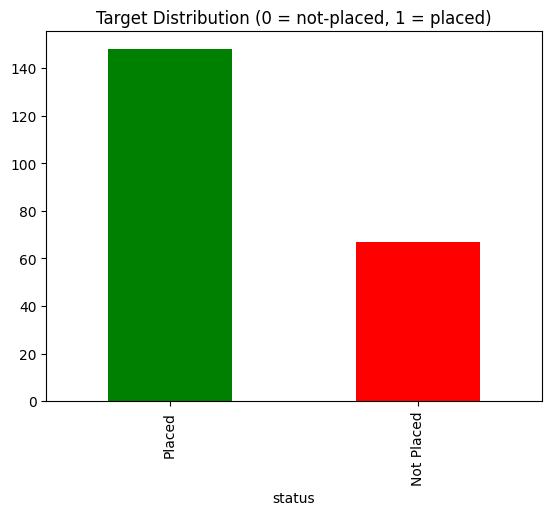

In [10]:
df['status'].value_counts().plot(kind='bar',color=['green','red'])

print(df['status'].value_counts())

plt.title('Target Distribution (0 = not-placed, 1 = placed)')
plt.savefig(os.path.join(output_dir, 'target_distribution.png'))

## Missing Values

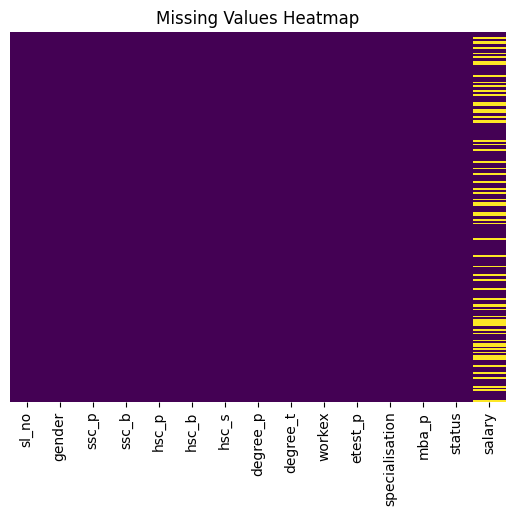

In [11]:
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

plt.title('Missing Values Heatmap')
plt.savefig(os.path.join(output_dir, 'missing_values_heatmap.png'))